### Who Are This Business's Best Customers?

A retail superstore has hundreds of customers, but is every customer equally valuable? And is the customer who spends the most actually the customer who makes the most money?

In this project, I will explore the data using Python and Pandas to find the answers and turn the numbers into real business insights.

Dataset: Superstore Sales (Kaggle)
Tools: Python, Pandas, Matplotlib, Seaborn

### Step 1 : Loading the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 25)

### Step 2: Loading the Data

In [2]:
df = pd.read_csv(r"D:\Data Science Project\superstore-customer-analysis\data\raw\Sample - Superstore.csv", encoding="latin-1")
print(f"Rows: {df.shape[0]}, Unique customers: {df['Customer Name'].nunique()}")
df.head()

Rows: 9994, Unique customers: 793


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Step 3 : Grouping by Customer


In [3]:
customer_summary = df.groupby("Customer Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Order_Count=("Order ID", "nunique")
).reset_index()
customer_summary.head()

,Customer Name,Total_Sales,Total_Profit,Order_Count
0,Aaron Bergman,886.156,129.3465,3
1,Aaron Hawkins,1744.700,365.2152,7
2,Aaron Smayling,3050.692,-253.5746,7
3,Adam Bellavance,7755.620,2054.5885,8
4,Adam Hart,3250.337,281.1890,10


#### Step 4 :: Top 10 Customers by Total Sales

In [4]:
customer_summary.sort_values("Total_Sales", ascending=False).head(10)

,Customer Name,Total_Sales,Total_Profit,Order_Count
686,Sean Miller,25043.050,-1980.7393,5
730,Tamara Chand,19052.218,8981.3239,5
622,Raymond Buch,15117.339,6976.0959,6
757,Tom Ashbrook,14595.620,4703.7883,4
6,Adrian Barton,14473.571,5444.8055,10
441,Ken Lonsdale,14175.229,806.8550,12
671,Sanjit Chand,14142.334,5757.4119,9
334,Hunter Lopez,12873.298,5622.4292,6
672,Sanjit Engle,12209.438,2650.6769,11
156,Christopher Conant,12129.072,2177.0493,5


### Step 5 : Top 10 Customers by Order Count

In [5]:
customer_summary.sort_values("Order_Count", ascending=False).head(10)

,Customer Name,Total_Sales,Total_Profit,Order_Count
259,Emily Phan,5478.0608,144.9578,17
663,Sally Hughsby,3406.8395,558.4740,13
574,Noel Staavos,2964.8230,-234.7714,13
586,Patrick Gardner,3086.9070,137.4613,13
791,Zuschuss Carroll,8025.7070,-1032.1490,13
381,Joel Eaton,6760.8150,221.7967,13
267,Erin Ashbrook,2846.7050,-52.7406,13
145,Chloris Kastensmidt,3154.8550,141.2831,13
728,Suzanne McNair,5563.3920,581.5742,12
629,Rick Bensley,4715.4660,640.5466,12


Step 6: Performance by Segment

In [6]:
segment = df.groupby("Segment").agg(Total_Sales=("Sales","sum"), Total_Profit=("Profit","sum"))
segment["Margin_percent"] = (segment["Total_Profit"]/segment["Total_Sales"]*100).round(1)
segment.sort_values("Total_Sales", ascending=False)

,Total_Sales,Total_Profit,Margin_percent
Segment,,,
Consumer,1.161401e+06,134119.2092,11.5
Corporate,7.061464e+05,91979.1340,13.0
Home Office,4.296531e+05,60298.6785,14.0


### Step 7: The Mystery Question

In [7]:
sean = customer_summary[customer_summary["Customer Name"]=="Sean Miller"]
sean

,Customer Name,Total_Sales,Total_Profit,Order_Count
686,Sean Miller,25043.05,-1980.7393,5


#### Step 8 Visulization 1 Top 10 Customers by Sales

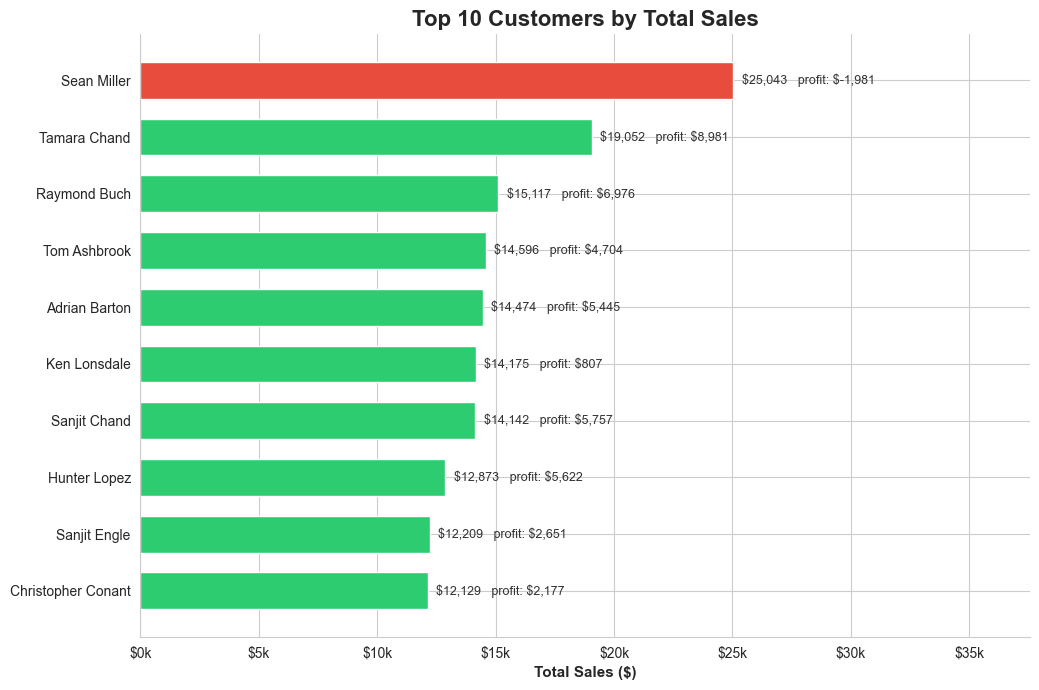

In [8]:
top10 = customer_summary.sort_values("Total_Sales", ascending=False).head(10).iloc[::-1]
colors = ["#e74c3c" if p < 0 else "#2ecc71" for p in top10["Total_Profit"]]

fig, ax = plt.subplots(figsize=(10.5, 7))
bars = ax.barh(top10["Customer Name"], top10["Total_Sales"], color=colors, edgecolor="white", height=0.65)

for bar, sales, profit in zip(bars, top10["Total_Sales"], top10["Total_Profit"]):
    label = f"\\${sales:,.0f}   profit: \\${profit:,.0f}"
    ax.text(bar.get_width() + 350, bar.get_y() + bar.get_height()/2, label,
            va='center', fontsize=9, color="#333333")

ax.set_title("Top 10 Customers by Total Sales", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Sales ($)", fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, top10["Total_Sales"].max()*1.5)

plt.tight_layout()
plt.show()

### From the Visualization 1
The top-spending customer, Sean Miller, is actually the only unprofitable customer in the top 10, standing out clearly in red against the rest.


Step 9: Visualization 2, Sales and Profit by Segment

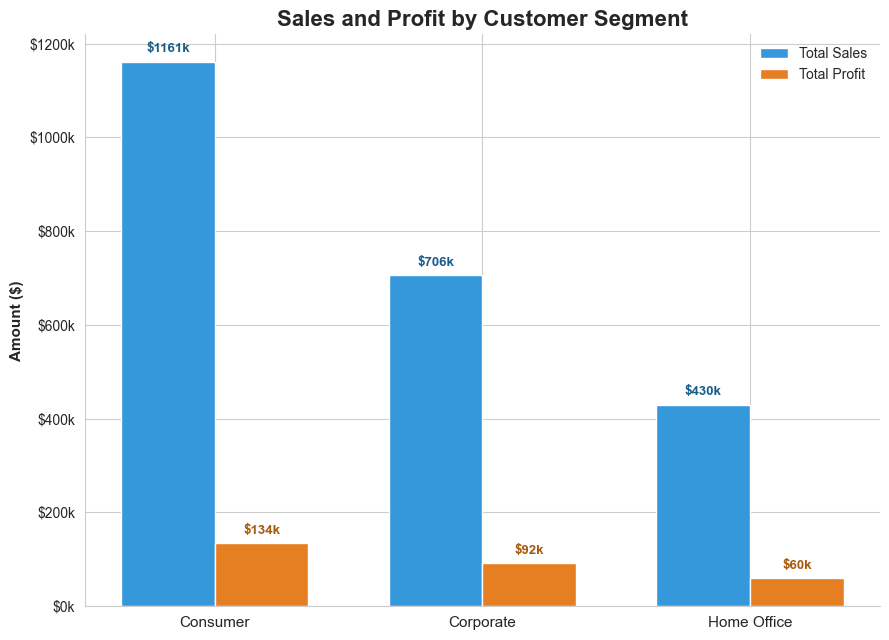

In [9]:
seg = df.groupby("Segment").agg(Total_Sales=("Sales","sum"), Total_Profit=("Profit","sum")).reset_index()
seg = seg.sort_values("Total_Sales", ascending=False)

x = range(len(seg))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 6.5))
bars1 = ax.bar([i - width/2 for i in x], seg["Total_Sales"], width, label="Total Sales", color="#3498db")
bars2 = ax.bar([i + width/2 for i in x], seg["Total_Profit"], width, label="Total Profit", color="#e67e22")

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20000, f"${bar.get_height()/1000:.0f}k",
            ha='center', fontsize=9.5, fontweight='bold', color="#1a5c8a")
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20000, f"${bar.get_height()/1000:.0f}k",
            ha='center', fontsize=9.5, fontweight='bold', color="#a85a0c")

ax.set_xticks(list(x))
ax.set_xticklabels(seg["Segment"], fontsize=11)
ax.set_title("Sales and Profit by Customer Segment", fontsize=16, fontweight="bold")
ax.set_ylabel("Amount ($)", fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

### From the Visulization 2
Consumer brings in the most total sales, but its profit is proportionally small compared to its size, while Home Office earns far less in sales yet converts a larger share of it into profit.


### Step 10: Business Recommendations
1. Do not equate high spending with a good customer. Sean Miller should be reviewed individually, what was actually purchased and at what discount, before treating him as a top customer.
2. Investigate the frequent but unprofitable repeat customers. Losing money on customers who order often is a bigger long term risk than one large unprofitable order.
3. Shift marketing focus toward Home Office. It has the smallest sales volume but the best profit margin of the three segments.


### Conclusion
This analysis shows that high sales do not always lead to high profit. Sean Miller has the highest sales, but the business is actually losing money on him. On the other hand, some mid-tier customers are more valuable because they generate better profits. Consumer brings in the most revenue but has the lowest margin, while Home Office has lower sales but a better margin. Overall, the business should look at profit and customer value, not just sales, when making decisions.